In [32]:
# install.packages('lmtest')

In [59]:
# cluster-boot
library(lmtest) ; library(sandwich)
rm(list=ls())
# data sim
x <- rnorm(1000)
y <- 5 + 2*x + rnorm(1000)
# regression
summary(lm(y~x))


# cluster bootstrap function
clusbootreg <- function(formula, data, cluster, reps=1000){
  reg1 <- lm(formula, data)
  clusters <- names(table(cluster))
  print(clusters)
  sterrs <- matrix(NA, nrow=reps, ncol=length(coef(reg1)))
  for(i in 1:reps){
    index <- sample(1:length(clusters), length(clusters), replace=TRUE)
    # print(index)
    aa <- clusters[index]
    bb <- table(aa)
    bootdat <- NULL
    for(j in 1:max(bb)){
      cc <- data[cluster %in% names(bb[bb %in% j]),]
      for(k in 1:j){
        bootdat <- rbind(bootdat, cc)
      }
    }
    print(bootdat$Cluster)
    
    sterrs[i,] <- coef(lm(formula, bootdat))
  }
  val <- cbind(coef(reg1),apply(sterrs,2,sd))
  colnames(val) <- c("Estimate","Std. Error")
  return(val)
}

dat <- data.frame(x=c(x,x,x),y=c(y,y,y),g=c(1:1000,1:1000,1:1000))
df_FM <- read.csv("../Output/df_FM.csv")
df_FM <- df_FM[which(df_FM$A02_Sex==1), ]

std_errors <- clusbootreg(formula = Household_ICV ~ Joint_Managed + Joint_Coop + Joint_Credit + Joint_Total_Processing_Access + ZoneID_1 + ZoneID_2 + ZoneID_3 + A03_Age + A05_Edu + Men_In_House + Women_In_House + Kids + A07_1_Main_occupatn_Farming + A07_1_Main_occupatn_Salaried_employment + A07_1_Main_occupatn_Self_employed_off_farm + A08_fam_lab_contributn,
                          data=df_FM, cluster=df_FM$Cluster, reps=10) #correct StErrs
std_errors


Call:
lm(formula = y ~ x)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.8772 -0.6887  0.0349  0.6696  3.6793 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.95925    0.03163  156.78   <2e-16 ***
x            1.98216    0.03117   63.59   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1 on 998 degrees of freedom
Multiple R-squared:  0.8021,	Adjusted R-squared:  0.8019 
F-statistic:  4044 on 1 and 998 DF,  p-value: < 2.2e-16


[1] "A" "B" "C" "D"
  [1] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [19] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [37] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [55] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [73] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
 [91] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "C" "C" "C" "C"
[109] "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C"
[127] "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C"
[145] "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C"
[163] "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "C" "A" "A"
[181] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
[199] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A" "A"
[217] "A" "A" "A" "A" "A" "A" "A" "A" "A" "A

,Estimate,Std. Error
(Intercept),0.857349350,0.553994797
Joint_Managed,0.329633428,0.063251049
Joint_Coop,0.298316650,0.060669037
Joint_Credit,-0.143306676,0.158785954
Joint_Total_Processing_Access,-0.030396141,0.019451768
ZoneID_1,-0.472251991,NA
ZoneID_2,0.290087557,NA
ZoneID_3,-0.557875733,NA
A03_Age,-0.002285826,0.006985674
A05_Edu,-0.007792824,0.017700151


In [111]:
cluster_sample_indices <- function(clusters, n) {
  # Check if n is valid
  if (n > length(clusters)) {
    stop("Sample size cannot be larger than the number of clusters")
  }

  half <- n/2
  # Shuffle the clusters
  cluster_indices <- sample(length(clusters)/2, half)

  # Select the first n cluster indices
  cluster_sample_indices <- c(cluster_indices[1:half], cluster_indices[1:half] + length(clusters)/2)

  return(cluster_sample_indices)
}

cluster_sample_indices <- cluster_sample_indices(df_FM$Cluster, 10)
print(cluster_sample_indices)

 [1]  701  441  189  396  146 1430 1170  918 1125  875


In [118]:
#library("oaxaca")
library(Formula)
source("Oaxaca/oaxaca.R")
df_FM <- read.csv("../Output/df_FM.csv")
results <- oaxaca(formula = Household_ICV ~ Joint_Managed + Joint_Coop + Joint_Credit + Joint_Total_Processing_Access + ZoneID_1 + ZoneID_2 + ZoneID_3 + A03_Age + A05_Edu + Men_In_House + Women_In_House + Kids + A07_1_Main_occupatn_Farming + A07_1_Main_occupatn_Salaried_employment + A07_1_Main_occupatn_Self_employed_off_farm + A08_fam_lab_contributn | A02_Sex  | ZoneID_1 + ZoneID_2 + ZoneID_3,
                  data=df_FM, R=1000, 
                  cluster=df_FM$Cluster
                 )

oaxaca: oaxaca() performing analysis. Please wait.


Bootstrapping standard errors:

1 / 1000 (0.1%)

100 / 1000 (10%)

200 / 1000 (20%)

300 / 1000 (30%)

400 / 1000 (40%)

500 / 1000 (50%)

600 / 1000 (60%)

700 / 1000 (70%)

800 / 1000 (80%)

900 / 1000 (90%)

1000 / 1000 (100%)



In [119]:
results$threefold$overall
results$threefold$variables
# plot(results, components = c("endowments"))

coef(endowments)     se(endowments) coef(coefficients)   se(coefficients) 
        0.07991631         0.07159226        -0.01678768         0.10332246 
 coef(interaction)    se(interaction) 
       -0.18521368         0.09317691

,coef(endowments),se(endowments),coef(coefficients),se(coefficients),coef(interaction),se(interaction)
(Intercept),0.000000000,0.000000e+00,-0.833862823,0.69087576,0.000000e+00,0.000000e+00
Joint_Managed,0.079582282,2.701426e-02,-0.023313862,0.11318422,-3.979864e-03,1.989475e-02
Joint_Coop,0.000818427,5.912764e-03,-0.043637404,0.03919383,-6.818344e-04,5.771733e-03
Joint_Credit,0.002555537,4.575738e-03,-0.003664726,0.05595092,2.035959e-04,4.915133e-03
Joint_Total_Processing_Access,0.018763050,2.362643e-02,0.170079071,0.09971357,-5.988700e-02,3.565442e-02
ZoneID_1,0.000000000,0.000000e+00,0.097276153,0.03065118,0.000000e+00,0.000000e+00
ZoneID_2,0.000000000,0.000000e+00,-0.061450657,0.04565448,0.000000e+00,0.000000e+00
ZoneID_3,0.000000000,0.000000e+00,-0.017870539,0.03312304,0.000000e+00,0.000000e+00
A03_Age,0.023105969,5.345680e-02,0.533561385,0.35586629,-1.067094e-01,7.137307e-02
A05_Edu,0.010230086,2.000254e-02,0.173485868,0.18099964,-2.437973e-02,2.603437e-02


In [42]:
oaxaca

function (formula, data, group.weights = NULL, R = 100, reg.fun = lm, 
    ...) 
{
    cl <- match.call()
    return(.oaxaca.wrap(formula = formula, data = data, group.weights = group.weights, 
        R = R, reg.fun = reg.fun, cl = cl, ...))
}
<bytecode: 0x107c17ae0>
<environment: namespace:oaxaca>

In [109]:
BO_A <- GeneralOaxaca(formula = Household_ICV ~ Household_Plots +
            A03_Age + A05_Edu +  A08_fam_lab_contributn + Men_In_House + 
            Women_In_House + Kids, family= gaussian, data=df_FM,       
                      groupInd=df_FM$A02_Sex,B=100)

BO_A$threefold

,value,prop (%),s.e,z value,P(>|z|),CI_l,CI_u
char,0.0002425375,0.04836105,0.06726566,0.003605667,0.4986,-0.127085451,0.1365911
coeff,0.1897145808,37.82835604,0.09046879,2.097016821,0.0180,0.009416707,0.3640479
int,0.3115570913,62.12328291,0.14710122,2.117977619,0.0171,0.018908006,0.5955342


In [115]:
zval <- 0.046/0.039
2*pnorm(-abs(zval))
zval

[1] 0.2382042

[1] 1.179487

In [126]:
x<-0.0002425375+0.1897145808+0.3115570913
0.3115570913/x


[1] 0.6212328

In [120]:
0.0002425375/BO_A$summaryStat$meandiff
0.1897145808/BO_A$summaryStat$meandiff
0.3115570913/BO_A$summaryStat$meandiff

[1] 0.001986627

[1] 1.553954

[1] 2.551968

In [7]:
data("chicago")
chicago$real.wage <- exp(chicago$ln.real.wage)

results <- oaxaca(formula = real.wage ~ age + female + LTHS +
+ some.college + college + advanced.degree | foreign.born | LTHS +
+ some.college + college + advanced.degree, data = chicago, R = 1000)

oaxaca: oaxaca() performing analysis. Please wait.


Bootstrapping standard errors:

1 / 1000 (0.1%)

100 / 1000 (10%)

200 / 1000 (20%)

300 / 1000 (30%)

400 / 1000 (40%)

500 / 1000 (50%)

600 / 1000 (60%)

700 / 1000 (70%)

800 / 1000 (80%)

900 / 1000 (90%)

1000 / 1000 (100%)



In [8]:
results$threefold$overall

coef(endowments)     se(endowments) coef(coefficients)   se(coefficients) 
         1.6165339          0.6385741          2.8333261          0.8720649 
 coef(interaction)    se(interaction) 
        -1.4342857          0.7823770


Call:
NULL

Residuals:
    Min      1Q  Median      3Q     Max 
-6.1830 -1.0109  0.4289  0.9770  6.6359 

Coefficients:
                         Estimate Std. Error t value Pr(>|t|)    
(Intercept)            -0.4119502  0.2086159  -1.975   0.0485 *  
Household_Plots         0.6395570  0.0235874  27.114   <2e-16 ***
A03_Age                -0.0013914  0.0032515  -0.428   0.6688    
A05_Edu                -0.0071119  0.0077798  -0.914   0.3608    
A08_fam_lab_contributn -0.0001923  0.0014859  -0.129   0.8971    
Men_In_House            0.0705682  0.0285876   2.468   0.0137 *  
Women_In_House          0.0351673  0.0296056   1.188   0.2351    
Kids                    0.0243475  0.0168483   1.445   0.1486    
A02_Sex                 0.1639462  0.0824526   1.988   0.0470 *  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.386 on 1449 degrees of freedom
Multiple R-squared:  0.3501,	Adjusted R-squared:  0.3465 
F-statistic: 97.56 on 8 and 1449 DF

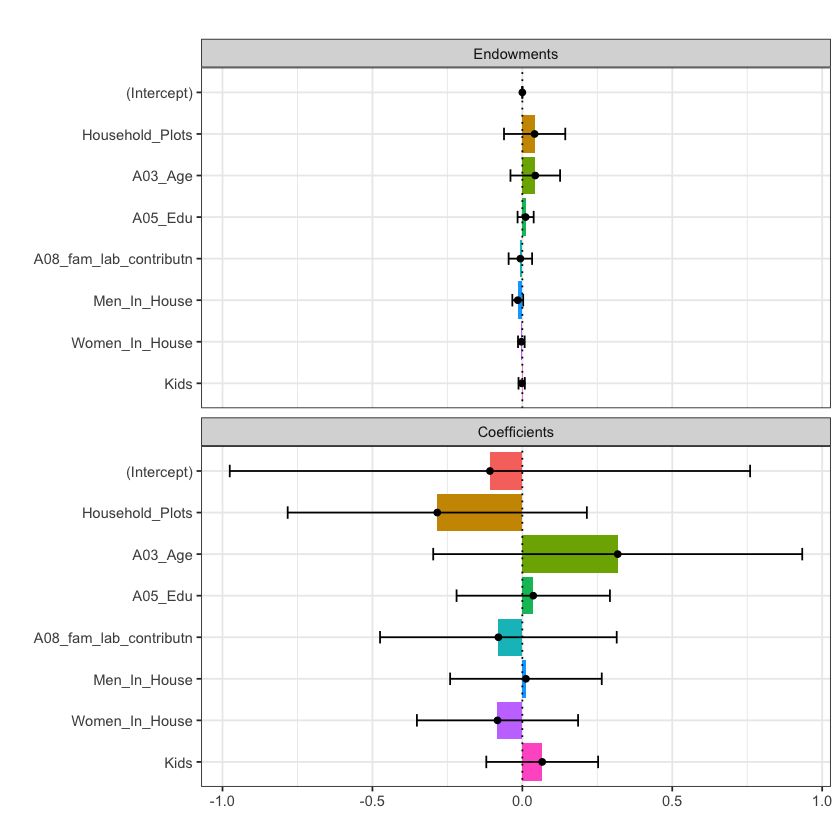

In [23]:
plot(results, components = c("endowments","coefficients"))
summary(results$reg$reg.pooled.2)

In [45]:
chicago$real.wage=exp(chicago$ln.real.wage)
formula=ln.real.wage~ age + female + LTHS + some.college + college +
advanced.degree
# exemple with gamma distribution
BO_A <- GeneralOaxaca(formula, family= Gamma, data=chicago,
groupInd=chicago$foreign.born,B=100)
BO_A#$twofold
BO_A#$regoutput$GroupA
BO_A#$threefold

$regoutput
$regoutput$GroupA

Call:  stats::glm(formula = formula, family = family, data = dataA, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
        0.41551         -0.00085          0.03040          0.02727  
   some.college          college  advanced.degree  
       -0.02262         -0.03082         -0.10662  

Degrees of Freedom: 378 Total (i.e. Null);  372 Residual
  (34 observations deleted due to missingness)
Null Deviance:	    11.83 
Residual Deviance: 8.811 	AIC: 366.1

$regoutput$GroupB

Call:  stats::glm(formula = formula, family = family, data = dataB, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
       0.434215        -0.001756         0.040026         0.033517  
   some.college          college  advanced.degree  
      -0.019252        -0.063398        -0.082271  

Degrees of Freedom: 286 Total (i.e. Null);  280 Residual
  (12 observations deleted due to missingnes

$regoutput
$regoutput$GroupA

Call:  stats::glm(formula = formula, family = family, data = dataA, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
        0.41551         -0.00085          0.03040          0.02727  
   some.college          college  advanced.degree  
       -0.02262         -0.03082         -0.10662  

Degrees of Freedom: 378 Total (i.e. Null);  372 Residual
  (34 observations deleted due to missingness)
Null Deviance:	    11.83 
Residual Deviance: 8.811 	AIC: 366.1

$regoutput$GroupB

Call:  stats::glm(formula = formula, family = family, data = dataB, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
       0.434215        -0.001756         0.040026         0.033517  
   some.college          college  advanced.degree  
      -0.019252        -0.063398        -0.082271  

Degrees of Freedom: 286 Total (i.e. Null);  280 Residual
  (12 observations deleted due to missingnes

$regoutput
$regoutput$GroupA

Call:  stats::glm(formula = formula, family = family, data = dataA, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
        0.41551         -0.00085          0.03040          0.02727  
   some.college          college  advanced.degree  
       -0.02262         -0.03082         -0.10662  

Degrees of Freedom: 378 Total (i.e. Null);  372 Residual
  (34 observations deleted due to missingness)
Null Deviance:	    11.83 
Residual Deviance: 8.811 	AIC: 366.1

$regoutput$GroupB

Call:  stats::glm(formula = formula, family = family, data = dataB, 
    x = TRUE)

Coefficients:
    (Intercept)              age           female             LTHS  
       0.434215        -0.001756         0.040026         0.033517  
   some.college          college  advanced.degree  
      -0.019252        -0.063398        -0.082271  

Degrees of Freedom: 286 Total (i.e. Null);  280 Residual
  (12 observations deleted due to missingnes